# Anomaly Detection 2 — Device load vs external temperature

**MAPD-B Project 3, section 3.3.2 — Group 5**

Goal: identify possible correlations between the loading percentage of the
devices and the external temperature.

| Variable | Meaning | Unit | Decimals |
|---|---|---|---|
| `S125` | Capacity Circuit 1 | % | 0 |
| `S181` | Capacity Circuit 2 | % | 0 |
| `S41`  | External temperature | °C | 1 |

**Naming convention.** Every variable in this section is prefixed with `t2_`
so the notebook can be merged with the other tasks without collisions. The
only exceptions are `spark`, `access_key` and `secret_key`, which in the
merged notebook must be defined **once** at the top and shared: this section
neither creates its own SparkSession nor calls `spark.stop()` midway.

**Decimal scaling.** Table 3 of the assignment specifies the number of
implicit decimals for each variable. `S41` has 1 decimal, so a raw value of
`153` means `15.3 °C` and must be divided by 10. `S125` and `S181` have 0
decimals and are used as they are. Skipping this step inflates every
temperature by a factor of ten and makes the analysis meaningless.

**Methodological note.** The physical expectation is that load increases at
*extreme* temperatures — both cold and hot — because the compressors have to
work harder in either case. If the relationship is U-shaped, the Pearson
coefficient can come out close to zero despite a strong association, since it
only captures the linear component. The analysis therefore complements Pearson
with the **mean load per temperature bin**, which also reveals non-monotonic
relationships.

## 1. Spark session setup

In [1]:
import os
import time
import statistics

from pyspark.sql import SparkSession
from pyspark.sql import functions as sf
from pyspark.sql import Window

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Credentials come from environment variables (see Appendix A of the handout).
# Note: if the kernel was not started from a login shell, .bashrc is never
# sourced and getenv returns None. Export them manually in that case.
access_key = os.getenv("S3_ACCESS_KEY")
secret_key = os.getenv("S3_PRIVATE_KEY") or os.getenv("S3_SECRET_KEY")

print(f"Access key found: {access_key is not None}")
print(f"Secret key found: {secret_key is not None}")

Access key found: True
Secret key found: True


In [3]:
spark = SparkSession.builder \
    .master("spark://master:7077") \
    .appName("AnomalyDetection2_LoadVsTemperature") \
    .config("spark.executor.memory", "1536m") \
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.4.1,org.apache.hadoop:hadoop-common:3.4.1") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .config("spark.hadoop.fs.s3a.access.key", access_key) \
    .config("spark.hadoop.fs.s3a.secret.key", secret_key) \
    .config("spark.hadoop.fs.s3a.endpoint", "https://cloud-areapd.pd.infn.it:5210") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.metadatastore.impl",
            "org.apache.hadoop.fs.s3a.s3guard.NullMetadataStore") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print(f"master:             {spark.sparkContext.master}")
print(f"defaultParallelism: {spark.sparkContext.defaultParallelism}")

:: loading settings :: url = jar:file:/usr/local/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/agonzati/.ivy2.5.2/cache
The jars for the packages stored in: /home/agonzati/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
org.apache.hadoop#hadoop-common added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f9e77d65-2451-4390-b0a7-cf7e77ed6d90;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
	found org.apache.hadoop#hadoop-common;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-protobuf_3_25;1.3.0 in central
	found org.apache.hadoop#hadoop-annotations;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-guava;1.3.0 in central
	found com.google.guava#guava;27.0-jre in central
	found com.google.guava#failure

master:             spark://master:7077
defaultParallelism: 4


## 2. Reading the data

The raw dataset is in **long** format: one row per measurement of a single
sensor (`when`, `hwid`, `metric`, `value`).

In [4]:
t2_DATA_PATH = "s3a://MAPDB-Group5/data_parquet"

t2_df_raw = spark.read.parquet(t2_DATA_PATH)
t2_df_raw.printSchema()
t2_df_raw.show(5, truncate=False)

root
 |-- when: long (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- value: integer (nullable = true)



+-------------+------+------+-----+
|when         |hwid  |metric|value|
+-------------+------+------+-----+
|1604265597702|SW-115|S80   |0    |
|1604265597702|SW-115|S73   |0    |
|1604265597702|SW-115|S72   |100  |
|1604265597702|SW-115|S71   |100  |
|1604265597702|SW-115|P16   |200  |
+-------------+------+------+-----+
only showing top 5 rows


## 3. Selecting the metrics of interest

Filtering *before* anything else drastically reduces the volume to resample and
to move across the network: out of the ~120 metrics in the dataset only three
are needed here. It is a *narrow* transformation, so it costs no shuffle.

In [5]:
t2_LOAD_COLS = ["S125", "S181"]     # capacity of circuits 1 and 2, in %
t2_TEMP_COL  = "S41"                 # external temperature, in deg C
t2_TARGET    = t2_LOAD_COLS + [t2_TEMP_COL]

# Implicit decimals from Table 3 of the assignment: the raw integers must be
# divided by 10**decimals to recover the physical value.
t2_DECIMALS = {"S125": 0, "S181": 0, "S41": 1}

t2_df = t2_df_raw.where(sf.col("metric").isin(t2_TARGET))

# Which metrics actually exist, and for which devices
t2_df.groupBy("hwid", "metric").count().orderBy("hwid", "metric").show(20)

+------+------+------+
|  hwid|metric| count|
+------+------+------+
|SW-065|  S125|211498|
|SW-065|  S181|207560|
|SW-065|   S41|211497|
|SW-088|  S125|323040|
|SW-088|  S181|316815|
|SW-088|   S41|323041|
|SW-106|  S125|200983|
|SW-106|  S181|197046|
|SW-106|   S41|200984|
|SW-115|  S125|354781|
|SW-115|  S181|348128|
|SW-115|   S41|354779|
+------+------+------+



## 4. Resampling to 1 minute

The sampling frequency ranges from 30 to 60 seconds, so it has to be
normalised.

All three variables are **continuous** (percentages and temperatures), so the
correct aggregation is the **mean**. The hint in the assignment about using
min/max applies to binary on/off variables, which do not appear here.

In [6]:
# "when" is a UNIX timestamp in milliseconds
t2_df = t2_df.withColumn("when", sf.timestamp_millis(sf.col("when")))

# Minute bucket: the common key across all metrics
t2_df = t2_df.withColumn("timestamp_bucket", sf.date_trunc("minute", sf.col("when")))

t2_df_resampled = (
    t2_df.groupBy("timestamp_bucket", "hwid", "metric")
         .agg(sf.mean("value").alias("value"))
)

t2_df_resampled.show(5, truncate=False)

+-------------------+------+------+-----+
|timestamp_bucket   |hwid  |metric|value|
+-------------------+------+------+-----+
|2021-01-02 04:28:00|SW-088|S41   |81.0 |
|2021-01-02 04:39:00|SW-088|S41   |86.0 |
|2021-01-02 05:11:00|SW-088|S41   |31.0 |
|2021-01-02 05:33:00|SW-088|S41   |30.0 |
|2021-01-02 05:40:00|SW-088|S41   |32.0 |
+-------------------+------+------+-----+
only showing top 5 rows


## 5. Pivot long → wide

To correlate two variables they must sit **on the same row**. The `pivot` turns
the values of the `metric` column into actual columns.

Passing the explicit list of expected values spares Spark a preliminary job to
discover them, so it is more efficient.

In [7]:
t2_df_wide = (
    t2_df_resampled.groupBy("timestamp_bucket", "hwid")
                   .pivot("metric", t2_TARGET)      # explicit list = faster
                   .agg(sf.first("value"))
)

# Apply the decimal scaling of Table 3. Without this step S41 is off by a
# factor of ten: a raw 153 would read as 153 deg C instead of 15.3 deg C.
for t2_c, t2_d in t2_DECIMALS.items():
    if t2_d > 0:
        t2_df_wide = t2_df_wide.withColumn(t2_c, sf.col(t2_c) / (10 ** t2_d))

t2_df_wide = t2_df_wide.cache()
t2_n_rows = t2_df_wide.count()
print(f"Rows (device x minute): {t2_n_rows:,}")
t2_df_wide.show(5)

Rows (device x minute): 671,851
+-------------------+------+----+----+-----+
|   timestamp_bucket|  hwid|S125|S181|  S41|
+-------------------+------+----+----+-----+
|2021-03-08 23:24:00|SW-088| 0.0| 0.0|12.05|
|2021-03-24 11:16:00|SW-115| 0.0| 0.0| 14.6|
|2021-03-30 05:56:00|SW-115|57.0|57.0|  6.6|
|2020-12-17 10:35:00|SW-115|43.0|57.0| 10.1|
|2020-12-22 19:28:00|SW-115| 0.0| 0.0|  9.8|
+-------------------+------+----+----+-----+
only showing top 5 rows


In [8]:
# Sanity check on the physical ranges: after scaling, the temperature must
# look like an outdoor temperature and the loads must lie within 0-100%.
t2_df_wide.select(
    sf.min(t2_TEMP_COL).alias("temp_min"), sf.max(t2_TEMP_COL).alias("temp_max"),
    sf.min("S125").alias("S125_min"),      sf.max("S125").alias("S125_max"),
    sf.min("S181").alias("S181_min"),      sf.max("S181").alias("S181_max"),
    sf.min("timestamp_bucket").alias("from"), sf.max("timestamp_bucket").alias("to"),
).show(truncate=False)

+--------+--------+--------+--------+--------+--------+-------------------+-------------------+
|temp_min|temp_max|S125_min|S125_max|S181_min|S181_max|from               |to                 |
+--------+--------+--------+--------+--------+--------+-------------------+-------------------+
|-11.0   |34.0    |0.0     |100.0   |0.0     |100.0   |2020-10-01 00:00:00|2021-03-31 23:59:00|
+--------+--------+--------+--------+--------+--------+-------------------+-------------------+



### Variable coverage per device

A device may have only circuit 1, only circuit 2, or both. Knowing which is the
case matters before correlating: an entirely null column yields a `None`
correlation, not a zero.

In [9]:
t2_coverage = t2_df_wide.groupBy("hwid").agg(
    sf.count("*").alias("n_minutes"),
    *[sf.count(c).alias(f"non_null_{c}") for c in t2_TARGET]
).orderBy("hwid")

t2_coverage.show()
t2_pdf_cov = t2_coverage.toPandas()

+------+---------+-------------+-------------+------------+
|  hwid|n_minutes|non_null_S125|non_null_S181|non_null_S41|
+------+---------+-------------+-------------+------------+
|SW-065|   136288|       135219|       132608|      135218|
|SW-088|   191997|       190827|       187038|      190827|
|SW-106|   105879|       105684|       103636|      105684|
|SW-115|   237687|       236532|       232120|      236531|
+------+---------+-------------+-------------+------------+



All four devices carry both circuits, and both are populated for
essentially every recorded minute. The assignment's caveat that "a device can
have one or both of these variables" therefore does not bite on this sample,
but the code handles the general case anyway, since a missing circuit must be
treated as absent rather than as a circuit sitting at zero.

## 6. Overall device load

Beyond the two circuits taken separately, a synthetic load figure is useful.
We use the **mean of the circuits that are actually present**: `S125` and
`S181` are both percentages on the same scale, so their mean is directly
interpretable. Where neither is present the result stays null.

In [10]:
# coalesce(col, lit(0)) would replace nulls with zeros and bias the mean
# downwards: only the non-null circuits are counted instead.
t2_n_present = sum(sf.when(sf.col(c).isNotNull(), 1).otherwise(0) for c in t2_LOAD_COLS)
t2_sum_load  = sum(sf.coalesce(sf.col(c), sf.lit(0.0)) for c in t2_LOAD_COLS)

t2_df_wide = t2_df_wide.withColumn(
    "load_avg", sf.when(t2_n_present > 0, t2_sum_load / t2_n_present)
)

t2_df_wide.select("hwid", "timestamp_bucket", *t2_TARGET, "load_avg").show(5)

+------+-------------------+----+----+-----+--------+
|  hwid|   timestamp_bucket|S125|S181|  S41|load_avg|
+------+-------------------+----+----+-----+--------+
|SW-088|2021-03-08 23:24:00| 0.0| 0.0|12.05|     0.0|
|SW-115|2021-03-24 11:16:00| 0.0| 0.0| 14.6|     0.0|
|SW-115|2021-03-30 05:56:00|57.0|57.0|  6.6|    57.0|
|SW-115|2020-12-17 10:35:00|43.0|57.0| 10.1|    50.0|
|SW-115|2020-12-22 19:28:00| 0.0| 0.0|  9.8|     0.0|
+------+-------------------+----+----+-----+--------+
only showing top 5 rows


Each row is one (device, minute) pair — the five shown here are a sample of
671 851, so the same device appears many times over.



`SW-115` has its two circuits at 57% and 43%, so they are controlled
independently and `load_avg` averages them to 50%. Those values are also
informative in themselves: 43% and 57% cannot come from on/off compressors,
which would only ever give 0, 50 or 100. At least one compressor per circuit
must modulate continuously — tested directly in section 11.

`SW-088` sits at zero on both circuits: idle. Those minutes are more than half
the dataset.

## 7. Hourly aggregation and idle periods

Two methodological choices must be made **before** computing any correlation,
because both change the result substantially.

**Time granularity.** External temperature varies slowly, over hours; the
compressor load fluctuates minute by minute following the control cycle.
Correlating at minute level therefore feeds the computation a lot of
high-frequency noise that temperature cannot possibly explain. Aggregating to
the hour compares two quantities on the same time scale.

**Idle periods.** When a device is off, `S125` and `S181` read 0. Including
those minutes answers the question *"is the device running?"* rather than
*"how hard is it working?"*: if idle stretches are long, they dominate the
computation and flatten the correlation.

Both questions are legitimate, but they must be kept apart. Below the
correlation is computed on both sets and the results are compared.

In [11]:
# Hourly bin, same convention as Task 1
t2_df_wide = t2_df_wide.withColumn("hour_bin", sf.date_trunc("hour", sf.col("timestamp_bucket")))

t2_df_hourly = t2_df_wide.groupBy("hwid", "hour_bin").agg(
    *[sf.mean(c).alias(c) for c in t2_TARGET],
    sf.mean("load_avg").alias("load_avg"),
    # fraction of minutes in which the device was actually working
    sf.mean(sf.when(sf.col("load_avg") > 0, 1.0).otherwise(0.0)).alias("active_fraction"),
).cache()

print(f"Hourly rows: {t2_df_hourly.count():,}")
t2_df_hourly.show(5)

Hourly rows: 13,052
+------+-------------------+------------------+------------------+------------------+------------------+------------------+
|  hwid|           hour_bin|              S125|              S181|               S41|          load_avg|   active_fraction|
+------+-------------------+------------------+------------------+------------------+------------------+------------------+
|SW-115|2020-12-24 14:00:00|19.682692307692307| 32.91346153846154|  6.31153846153846|26.298076923076923|0.8846153846153846|
|SW-065|2020-10-29 10:00:00|37.735849056603776|11.764705882352942| 16.29622641509434| 25.37037037037037|0.8333333333333334|
|SW-115|2021-02-26 09:00:00|             19.38|              7.72|             9.118|             13.55|              0.52|
|SW-106|2020-11-10 02:00:00|               0.0|               0.0|16.315773809523808|               0.0|               0.0|
|SW-065|2020-11-11 11:00:00| 23.50877192982456| 44.03508771929825|11.787719298245616|33.771929824561404|        

In [12]:
# How much do idle periods weigh?
t2_tot    = t2_df_wide.where(sf.col("load_avg").isNotNull()).count()
t2_idle   = t2_df_wide.where(sf.col("load_avg") == 0).count()

print(f"Minutes with known load: {t2_tot:,}")
print(f"Minutes at zero load:    {t2_idle:,}  ({100 * t2_idle / t2_tot:.1f}%)")
print(f"Minutes with load > 0:   {t2_tot - t2_idle:,}")

Minutes with known load: 671,850
Minutes at zero load:    360,336  (53.6%)
Minutes with load > 0:   311,514


Roughly **54% of the recorded minutes have zero load**: more than half the
time, these machines are not running at all.

That is expected of a thermal plant, it reaches its set-point and shuts off
until the temperature drifts back, but it changes what a correlation computed
on all rows actually measures. Including idle minutes answers "is the device
running?"; excluding them answers "how hard is it working?". Both questions
are legitimate and they have different answers, so from here on the two are
kept apart rather than silently merged.

## 8. Pearson correlation

Pearson measures the strength of the **linear** relationship between two
variables and ranges from -1 to +1. It is computed on three different sets, to
see how much the answer depends on the choices made above:

1. minute-level data, all rows;
2. hourly data, all rows;
3. hourly data, active hours only.

In [13]:
def t2_pearson(df, label):
    """Pearson of each load variable against temperature."""
    print(f"--- {label} ---")
    out = {}
    for c in t2_LOAD_COLS + ["load_avg"]:
        try:
            r = df.stat.corr(c, t2_TEMP_COL)
        except Exception:
            r = None
        out[c] = r
        print(f"  {c:9s} vs {t2_TEMP_COL}: "
              + (f"{r:+.4f}" if r is not None else "not computable"))
    return out


t2_corr_min    = t2_pearson(t2_df_wide,   "minute level, all rows")
t2_corr_hour   = t2_pearson(t2_df_hourly, "hourly, all rows")
t2_corr_active = t2_pearson(t2_df_hourly.where(sf.col("load_avg") > 0),
                            "hourly, active hours only")

--- minute level, all rows ---
  S125      vs S41: -0.1396
  S181      vs S41: -0.0891
  load_avg  vs S41: -0.1374
--- hourly, all rows ---
  S125      vs S41: -0.1751
  S181      vs S41: -0.0965
  load_avg  vs S41: -0.1569
--- hourly, active hours only ---
  S125      vs S41: -0.2379
  S181      vs S41: -0.1046
  load_avg  vs S41: -0.2125


In [14]:
# Compact comparison: is the result robust, or does it hinge on the choices?
t2_comparison = pd.DataFrame({
    "minute":        t2_corr_min,
    "hourly":        t2_corr_hour,
    "hourly active": t2_corr_active,
}).round(4)
t2_comparison

,minute,hourly,hourly active
S125,-0.1396,-0.1751,-0.2379
S181,-0.0891,-0.0965,-0.1046
load_avg,-0.1374,-0.1569,-0.2125


Rows are the load variables, columns the three datasets (minutes, hours,
active minutes only). Data from the 4 devices are all pooled together.

### Pearson per device

Different devices may have different sizes, circuits and operating regimes: an
average taken over the whole fleet can hide behaviours that point in opposite
directions — and in that case the fleet-level figure is not a summary but an
artefact of the cancellation.

In [15]:
t2_rows = []
for d in sorted(r["hwid"] for r in t2_df_hourly.select("hwid").distinct().collect()):
    sub = t2_df_hourly.where(sf.col("hwid") == d)
    rec = {"hwid": d}
    for c in t2_LOAD_COLS + ["load_avg"]:
        try:
            rec[c] = sub.stat.corr(c, t2_TEMP_COL)
        except Exception:
            rec[c] = None
    t2_rows.append(rec)
    vals = "  ".join(f"{k}={v:+.3f}" if isinstance(v, float) else f"{k}=n/a"
                     for k, v in rec.items() if k != "hwid")
    print(f"  {d}:  {vals}")

t2_pdf_corr = pd.DataFrame(t2_rows)

  SW-065:  S125=+0.691  S181=+0.704  load_avg=+0.767
  SW-088:  S125=-0.598  S181=-0.274  load_avg=-0.571
  SW-106:  S125=-0.250  S181=-0.241  load_avg=-0.269
  SW-115:  S125=-0.294  S181=-0.314  load_avg=-0.313


In [16]:
# Do the devices agree on the sign? If not, the fleet-level correlation is
# the average of opposing behaviours and must not be read as a summary.
t2_signs = t2_pdf_corr["load_avg"].dropna()
t2_pos = (t2_signs > 0).sum()
t2_neg = (t2_signs < 0).sum()

print(f"Devices with positive correlation: {t2_pos}")
print(f"Devices with negative correlation: {t2_neg}")
if t2_pos and t2_neg:
    print()
    print("WARNING: the devices disagree on the sign. The fleet-level")
    print("coefficient is therefore a cancellation artefact, not a summary:")
    print("the per-device figures are the ones to report.")

Devices with positive correlation: 1
Devices with negative correlation: 3

coefficient is therefore a cancellation artefact, not a summary:
the per-device figures are the ones to report.


### What the coefficients say

Three devices out of four correlate **negatively** — they load up as it gets
colder, which is what a heating machine does. SW-065 correlates **positively**,
and more strongly than any of the others.

When all observations are pooled, these two groups pull the regression line in
opposite directions and largely cancel each other out. The resulting −0.16
describes none of the four machines: it is an artefact of mixing populations
that behave differently, and it disappears as soon as they are separated.

This is an instance of **Simpson's paradox** — a trend that appears, vanishes
or reverses depending on whether subgroups or the aggregate are examined. The
practical consequence is that the fleet-level figure must not be reported as
the result of this task. The four per-device figures are.

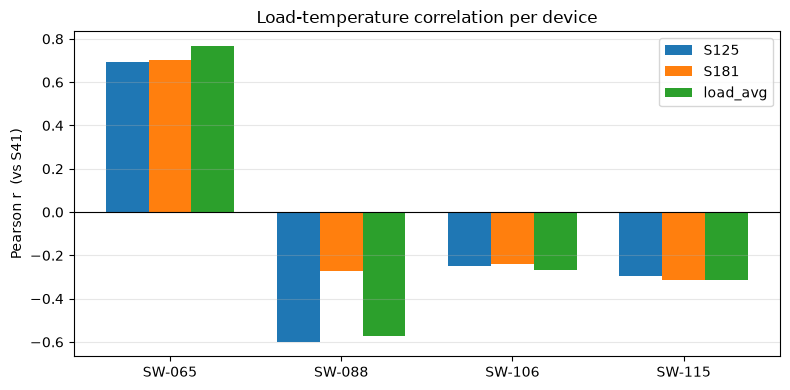

In [17]:
# Pearson coefficients per device, at a glance
fig, ax = plt.subplots(figsize=(8, 4))
t2_x = range(len(t2_pdf_corr))
bar_w = 0.25
for i, c in enumerate(t2_LOAD_COLS + ["load_avg"]):
    ax.bar([p + i * bar_w for p in t2_x], t2_pdf_corr[c].fillna(0),
           width=bar_w, label=c)
ax.set_xticks([p + bar_w for p in t2_x])
ax.set_xticklabels(t2_pdf_corr["hwid"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel(f"Pearson r  (vs {t2_TEMP_COL})")
ax.set_title("Load-temperature correlation per device")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Spearman correlation

Spearman is Pearson computed on **ranks** rather than raw values: it captures
any *monotonic* relationship, linear or not. A Spearman clearly larger in
magnitude than Pearson signals a strong but curved relationship.

Spark does not expose Spearman on `stat.corr`, but it follows from applying
Pearson to the rank-transformed columns via `percent_rank()`.

Note that these window functions have no `partitionBy`, so Spark moves all rows
to a single partition and warns about it. That is expected for a global rank
and harmless here, since the hourly table holds only a few thousand rows — it
would not be acceptable on the raw dataset.

In [18]:
t2_df_ok = t2_df_hourly.where(
    sf.col("load_avg").isNotNull() & sf.col(t2_TEMP_COL).isNotNull()
)

t2_df_ranked = (
    t2_df_ok.withColumn("rank_load", sf.percent_rank().over(Window.orderBy("load_avg")))
            .withColumn("rank_temp", sf.percent_rank().over(Window.orderBy(t2_TEMP_COL)))
)

t2_spearman = t2_df_ranked.stat.corr("rank_load", "rank_temp")
print(f"Spearman  load_avg vs {t2_TEMP_COL}: {t2_spearman:+.4f}")
print(f"Pearson   load_avg vs {t2_TEMP_COL}: {t2_corr_hour['load_avg']:+.4f}")

26/09/10 12:26:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/10 12:26:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/10 12:26:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/10 12:26:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/10 12:26:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/10 12:26:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/10 1

Spearman  load_avg vs S41: -0.0906
Pearson   load_avg vs S41: -0.1569


Spearman comes out **lower in magnitude than Pearson**, which is informative
in itself. Spearman detects any monotonic association, curved or not, so a
value near zero rules out the explanation *"the relationship is strong but
bends"*. What remains is a relationship that does not run in one direction at
all — which the next section confirms.

## 9. Mean load per temperature bin

This is the key step of the analysis. Grouping observations into temperature
intervals and averaging the load within each makes a **non-monotonic**
relationship visible: if load rises both in the cold and in the heat, the
profile takes a U shape that no linear correlation coefficient could reveal.

Bins with few samples are discarded, as their mean is unreliable. The first
table mixes all four devices — each bin averages over every device that
recorded a measurement in that temperature range — while the second keeps them
separate, since the previous section showed they may not behave alike.

In [19]:
t2_BIN_WIDTH = 2.0      # degrees Celsius
t2_MIN_COUNT = 50       # minimum samples for a bin to be trusted

t2_df_binned = t2_df_wide.where(
    sf.col(t2_TEMP_COL).isNotNull() & sf.col("load_avg").isNotNull()
).withColumn(
    "temp_bin", sf.floor(sf.col(t2_TEMP_COL) / t2_BIN_WIDTH) * t2_BIN_WIDTH
)

t2_profile = (
    t2_df_binned.groupBy("temp_bin")
                .agg(sf.mean("load_avg").alias("mean_load"),
                     sf.stddev("load_avg").alias("std_dev"),
                     sf.count("*").alias("n"))
                .where(sf.col("n") >= t2_MIN_COUNT)
                .orderBy("temp_bin")
)

# toPandas() is safe here: the profile has a few dozen rows
t2_pdf_profile = t2_profile.toPandas()
print(f"Temperature range covered: "
      f"{t2_pdf_profile['temp_bin'].min():.0f} to "
      f"{t2_pdf_profile['temp_bin'].max():.0f} deg C")
t2_pdf_profile.head(20)

Temperature range covered: -12 to 30 deg C


,temp_bin,mean_load,std_dev,n
0,-12.0,42.555000,16.004007,250
1,-10.0,47.319246,14.327007,1473
2,-8.0,49.088288,18.543727,2220
3,-6.0,38.123459,23.221876,3570
4,-4.0,24.353848,27.161934,4184
5,-2.0,23.115585,30.235080,10134
6,0.0,21.876766,32.176213,31610
7,2.0,22.068865,33.344726,55747
8,4.0,24.216093,31.851209,65284
9,6.0,20.169241,25.996133,66913


This table mixes all four devices: each bin averages over every device that
recorded a measurement in that temperature range.

In [20]:
# Same profile, per device
t2_prof_dev = (
    t2_df_binned.groupBy("hwid", "temp_bin")
                .agg(sf.mean("load_avg").alias("mean_load"),
                     sf.count("*").alias("n"))
                .where(sf.col("n") >= t2_MIN_COUNT)
                .orderBy("hwid", "temp_bin")
                .toPandas()
)
t2_prof_dev.head()

,hwid,temp_bin,mean_load,n
0,SW-065,-6.0,0.000000,117
1,SW-065,-4.0,0.000000,1237
2,SW-065,-2.0,0.936236,3215
3,SW-065,0.0,0.928146,11760
4,SW-065,2.0,1.983129,16300


The error bars are the **standard deviation inside each bin**: how spread out
the individual measurements are around the mean. They do not shrink when a bin
has more data, because they describe the data, not the precision of the mean.

They are widest in the mild range because those bins contain both idle
machines at 0% and fully loaded ones near 100%: the mean sits between two
groups rather than describing a typical value.

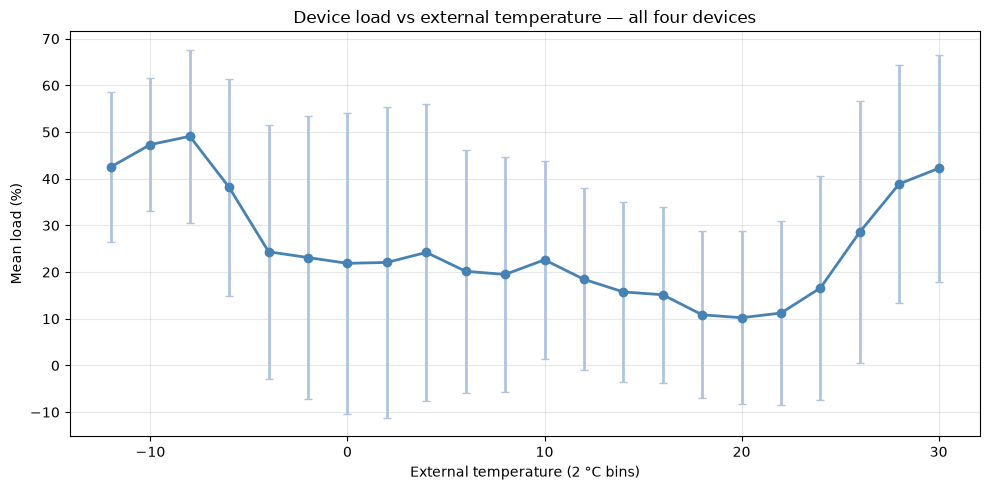

In [21]:
# Load profile vs temperature, all four devices pooled together
# (groupBy on temp_bin only - the per-device breakdown is the next plot).
plt.figure(figsize=(10, 5))
plt.errorbar(t2_pdf_profile["temp_bin"], t2_pdf_profile["mean_load"],
             yerr=t2_pdf_profile["std_dev"], marker="o", capsize=3,
             color="steelblue", ecolor="lightsteelblue", linewidth=2)
plt.xlabel(f"External temperature ({t2_BIN_WIDTH:g} °C bins)")
plt.ylabel("Mean load (%)")
plt.title("Device load vs external temperature — all four devices")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The error bars above say nothing about how much data each point rests on — a
bin with 200 measurements and one with 80 000 can have identical bars. This
plot supplies the missing piece: the coldest and warmest bins are supported by
far fewer observations than the mild ones, so the ends of the U are the less
reliable part of the curve.

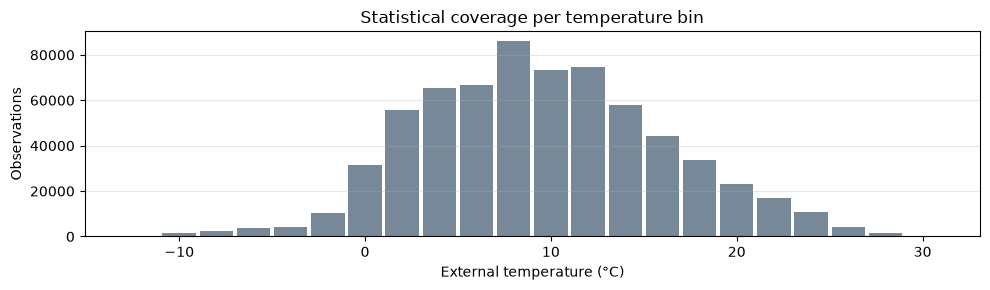

In [22]:
# Observations per bin: shows where the dataset is actually populated
plt.figure(figsize=(10, 3))
plt.bar(t2_pdf_profile["temp_bin"], t2_pdf_profile["n"],
        width=t2_BIN_WIDTH * 0.9, color="lightslategray")
plt.xlabel("External temperature (°C)")
plt.ylabel("Observations")
plt.title("Statistical coverage per temperature bin")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

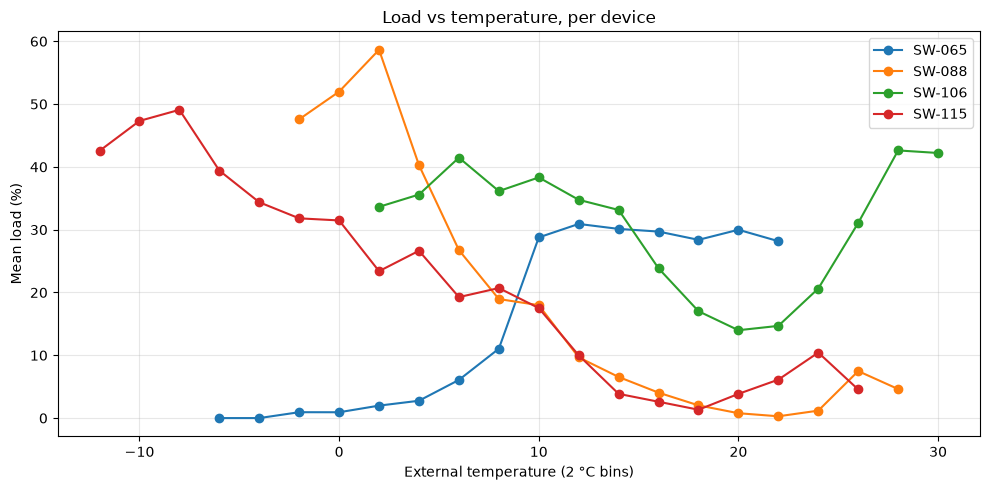

In [23]:
# Per-device profile: this is where opposite behaviours become visible
plt.figure(figsize=(10, 5))
for d, g in t2_prof_dev.groupby("hwid"):
    plt.plot(g["temp_bin"], g["mean_load"], marker="o", label=d)
plt.xlabel(f"External temperature ({t2_BIN_WIDTH:g} °C bins)")
plt.ylabel("Mean load (%)")
plt.title("Load vs temperature, per device")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The relationship is U-shaped

| Temperature | Mean load |
|---|---|
| −8 °C | 49.1% |
| −2 °C | 23.1% |
| 8 °C | 19.5% |
| **20 °C** | **10.2%** ← minimum |
| 26 °C | 28.6% |
| 30 °C | 42.2% |

Load falls steadily from the cold extreme to a minimum around 18–20 °C, then
climbs again, reaching at 30 °C roughly the level it had at −8 °C.

A linear coefficient computed on a symmetric U measures the average slope,
which is near zero by construction. **The conclusion is not "there is no
correlation" but "there is no linear correlation"** — and the distinction is
the whole point of computing the binned profile rather than stopping at
Pearson.

The physics behind each branch is the same. A reversible heat pump moves heat
across a temperature gap, and compressor work scales with the size of that
gap: when the outside air sits near the indoor set-point there is little to
move, and the further it drifts in either direction the harder the compressors
work. The position of the minimum is itself informative — 18–20 °C is
plausibly close to the set-point of the buildings served.

**But the pooled U is not the behaviour of a typical machine.** The per-device
profiles show that the devices cover different branches of it: SW-088 and
SW-115 produce the cold side and their load collapses towards 20 °C, SW-065
contributes almost only to the warm side because below 4 °C it is switched
off, and only SW-106 traces both branches on its own. The aggregate curve
therefore reflects the composition of the fleet as much as any single
machine's response, and each branch rests mostly on a different subset of
devices.

Both branches are measured rather than extrapolated, since the data spans
−11 °C to 34 °C. The warm branch nevertheless rests on far fewer observations
(4 260 minutes in the 26 °C bin against 86 065 at 8 °C), so it is the less
firmly established of the two.

### Circuit 1 vs circuit 2

The assignment names `S125` and `S181` separately, so it is worth asking
whether the two circuits behave alike. One panel per device rather than a
pooled curve: with one machine running the profile backwards, both circuit
averages would flatten the same way and look similar for the wrong reason.

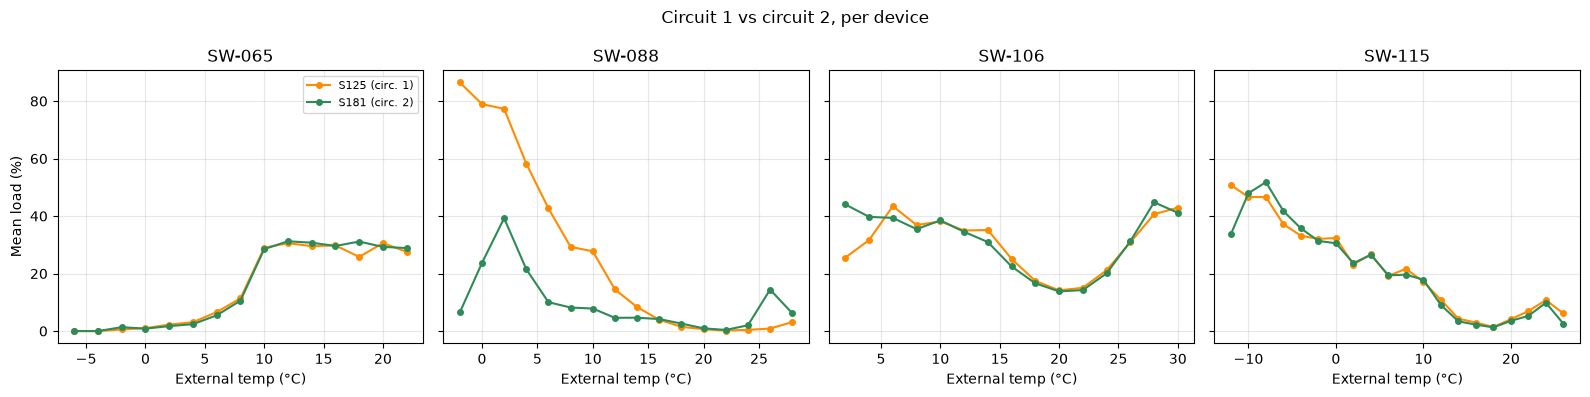

In [24]:
# Circuit 1 vs circuit 2, one panel per device.
# Pooling the devices would hide the answer: with one device running the curve
# backwards, both circuit averages get flattened the same way and end up
# looking alike for the wrong reason.
t2_circ = (
    t2_df_wide.where(sf.col(t2_TEMP_COL).isNotNull())
              .withColumn("temp_bin",
                          sf.floor(sf.col(t2_TEMP_COL) / t2_BIN_WIDTH) * t2_BIN_WIDTH)
              .groupBy("hwid", "temp_bin")
              .agg(*[sf.mean(c).alias(c) for c in t2_LOAD_COLS],
                   sf.count("*").alias("n"))
              .where(sf.col("n") >= t2_MIN_COUNT)
              .orderBy("hwid", "temp_bin")
              .toPandas()
)

t2_dev_list = sorted(t2_circ["hwid"].unique())
fig, axes = plt.subplots(1, len(t2_dev_list), figsize=(4 * len(t2_dev_list), 4),
                         sharey=True)
if len(t2_dev_list) == 1:
    axes = [axes]

for ax, d in zip(axes, t2_dev_list):
    g = t2_circ[t2_circ["hwid"] == d]
    for c, colour in zip(t2_LOAD_COLS, ["darkorange", "seagreen"]):
        ax.plot(g["temp_bin"], g[c], marker="o", markersize=4, color=colour,
                label=f"{c} (circ. {t2_LOAD_COLS.index(c) + 1})")
    ax.set_title(d)
    ax.set_xlabel("External temp (°C)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Mean load (%)")
axes[0].legend(fontsize=8)
plt.suptitle("Circuit 1 vs circuit 2, per device")
plt.tight_layout()
plt.show()

In [25]:
# Do the two circuits track each other? Correlating them directly answers it

print(f"{'device':8s} {'corr(S125, S181)':>18s} {'mean S125':>10s} {'mean S181':>10s}")
for d in t2_dev_list:
    sub = t2_df_wide.where(sf.col("hwid") == d)
    try:
        r = sub.stat.corr(*t2_LOAD_COLS)
    except Exception:
        r = float("nan")
    m1 = sub.agg(sf.mean(t2_LOAD_COLS[0])).collect()[0][0]
    m2 = sub.agg(sf.mean(t2_LOAD_COLS[1])).collect()[0][0]
    print(f"{d:8s} {r:>18.3f} {m1:>9.1f}% {m2:>9.1f}%")

print()
print("A high correlation means the circuits are staged together; a lower one")
print("means the second circuit comes in only under conditions the first")
print("cannot cover on its own.")

device     corr(S125, S181)  mean S125  mean S181
SW-065                0.379      15.5%      15.4%
SW-088                0.328      24.3%       8.6%
SW-106                0.561      27.1%      25.9%
SW-115                0.662      21.0%      20.6%

A high correlation means the circuits are staged together; a lower one
means the second circuit comes in only under conditions the first
cannot cover on its own.


### Do the circuits diverge over time?

SW-088 is the only device whose circuits correlate differently with
temperature. That could be normal staging, an unbalanced control strategy, or
one circuit degrading.

The time axis tells them apart: a constant gap across the whole period means
design or control, a step change at a date means something happened.

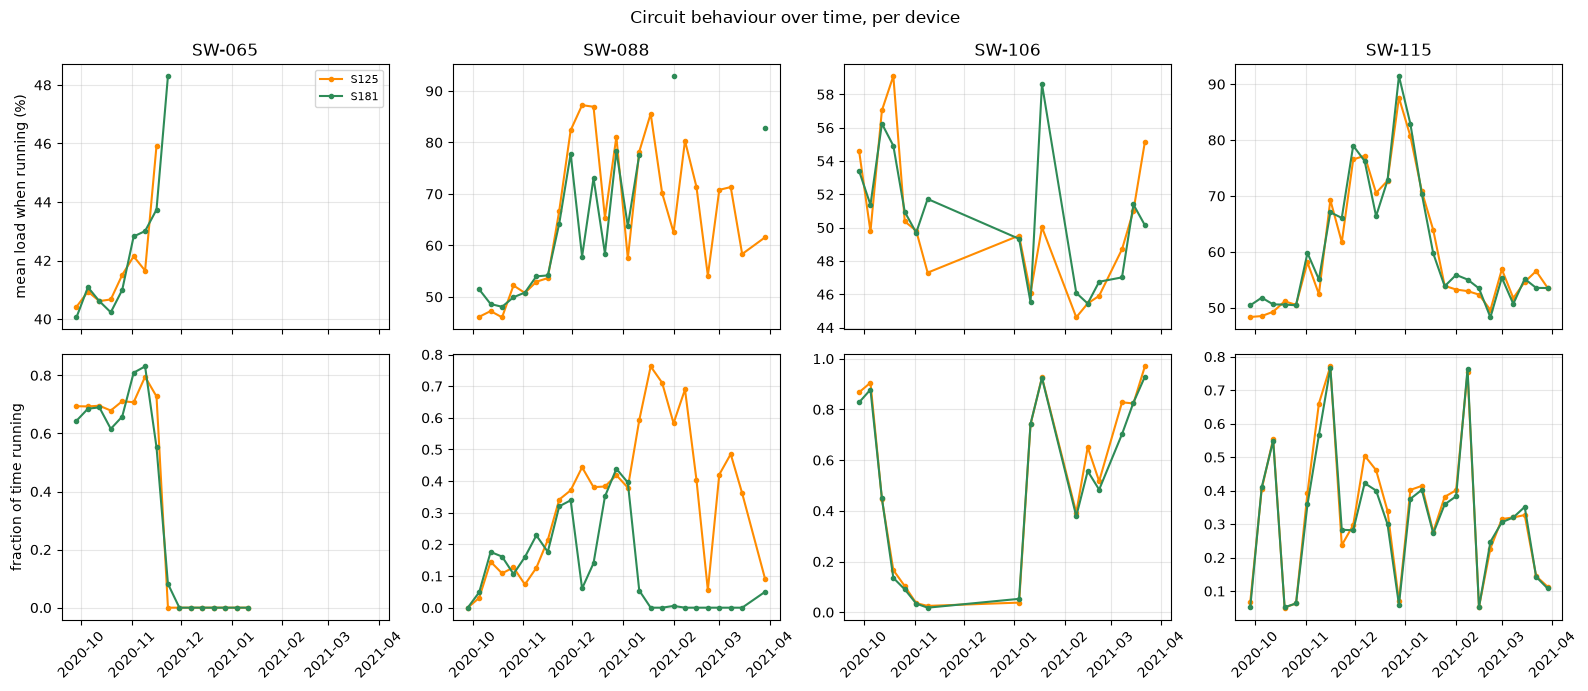

In [26]:
# Weekly behaviour of each circuit: mean load when running, and how often it
# runs. A fault shows up as a step change at a date, not as a constant offset.
t2_weekly = (
    t2_df_wide
    .withColumn("week", sf.date_trunc("week", sf.col("timestamp_bucket")))
    .groupBy("hwid", "week")
    .agg(*[sf.mean(sf.when(sf.col(c) > 0, sf.col(c))).alias(f"load_{c}")
           for c in t2_LOAD_COLS],
         *[sf.mean(sf.when(sf.col(c) > 0, 1.0).otherwise(0.0)).alias(f"active_{c}")
           for c in t2_LOAD_COLS],
         sf.count("*").alias("n"))
    .where(sf.col("n") >= 1000)          # drop partial weeks at the edges
    .orderBy("hwid", "week")
    .toPandas()
)

t2_devs = sorted(t2_weekly["hwid"].unique())
fig, axes = plt.subplots(2, len(t2_devs), figsize=(4 * len(t2_devs), 7), sharex=True)

for j, d in enumerate(t2_devs):
    g = t2_weekly[t2_weekly["hwid"] == d]
    for c, colour in zip(t2_LOAD_COLS, ["darkorange", "seagreen"]):
        axes[0, j].plot(g["week"], g[f"load_{c}"], marker=".", color=colour, label=c)
        axes[1, j].plot(g["week"], g[f"active_{c}"], marker=".", color=colour, label=c)
    axes[0, j].set_title(d)
    axes[1, j].tick_params(axis="x", rotation=45)
    for a in (axes[0, j], axes[1, j]):
        a.grid(alpha=0.3)

axes[0, 0].set_ylabel("mean load when running (%)")
axes[1, 0].set_ylabel("fraction of time running")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Circuit behaviour over time, per device")
plt.tight_layout()
plt.show()

In [27]:
# Is the gap between circuits stable, or does it move? A large spread in the
# monthly gap would indicate a change of regime rather than a fixed imbalance.
t2_gap = t2_weekly.copy()
t2_gap["gap"] = t2_gap[f"load_{t2_LOAD_COLS[0]}"] - t2_gap[f"load_{t2_LOAD_COLS[1]}"]

print(f"{'device':8s} {'mean gap':>10s} {'std':>8s} {'min':>8s} {'max':>8s}")
for d in t2_devs:
    g = t2_gap[t2_gap["hwid"] == d]["gap"].dropna()
    if len(g):
        print(f"{d:8s} {g.mean():>9.1f}pp {g.std():>7.1f} {g.min():>7.1f} {g.max():>7.1f}")

print()
print("A stable non-zero mean gap means one circuit systematically carries more")
print("of the load: staging or control, not a fault. A gap that shifts over the")
print("period would be the signature of something changing in the machine.")

device     mean gap      std      min      max
SW-065         0.2pp     1.0    -1.4     2.2
SW-088        -0.3pp    12.7   -30.4    29.4
SW-106        -0.3pp     3.1    -8.6     5.0
SW-115        -0.4pp     2.3    -4.3     4.2

A stable non-zero mean gap means one circuit systematically carries more
of the load: staging or control, not a fault. A gap that shifts over the
period would be the signature of something changing in the machine.


### What the weekly profiles show

**SW-088 loses circuit 2 in early January.** The green line follows the orange
until the first week of 2021, then drops to zero and never recovers, while
circuit 1 keeps running for the remaining three months and works harder than
before — its load rises from around 55% to 60–85%. Two isolated green points
appear afterwards and nothing else.

This is a step change at a date, not a constant offset, and it is what a fault
looks like. It also explains the finding that prompted this section: the two
circuits of SW-088 correlate differently with temperature (−0.60 against
−0.27) not because they are staged differently, but because circuit 2 only has
data for half the period.

The gap statistics say the same thing numerically: SW-088 shows a standard
deviation of 12.7 percentage points between the circuits, swinging from −30 to
+29, against 1.0 to 3.1 for the other three devices.

**SW-065 shuts down entirely in early December.** Both circuits stop in the
same week and neither restarts. Stopping together points to the machine being
switched off rather than to a component failing, and it fits the cooling
hypothesis: the device ran through October and November, the mild part of the
period, and was off for the winter.

This carries a caveat for the correlation reported earlier. SW-065's positive
correlation with temperature is confounded with time — the device was on
during the warm months and off during the cold ones — so it may follow a
seasonal schedule rather than respond to temperature itself.

**SW-106 and SW-115 behave normally**, with the two circuits tracking each
other across the whole period.

### Is the odd device really running in reverse?

One device correlates positively with temperature, suggesting it cools while
the others heat. But a simpler explanation gives the same correlation: it may
just be off in winter.

A cooling unit would still be switched on in winter, only lightly loaded. A
device that is off would show an active fraction of zero.

In [28]:
t2_activity = (
    t2_df_binned.groupBy("hwid", "temp_bin")
                .agg(sf.mean(sf.when(sf.col("load_avg") > 0, 1.0).otherwise(0.0))
                       .alias("active_fraction"),
                     sf.mean("load_avg").alias("mean_load_all"),
                     # mean load computed over running minutes only
                     sf.mean(sf.when(sf.col("load_avg") > 0, sf.col("load_avg")))
                       .alias("mean_load_running"),
                     sf.count("*").alias("n"))
                .where(sf.col("n") >= t2_MIN_COUNT)
                .orderBy("hwid", "temp_bin")
                .toPandas()
)
t2_activity.head(10).round(3)

,hwid,temp_bin,active_fraction,mean_load_all,mean_load_running,n
0,SW-065,-6.0,0.000,0.000,NaN,117
1,SW-065,-4.0,0.000,0.000,NaN,1237
2,SW-065,-2.0,0.044,0.936,21.197,3215
3,SW-065,0.0,0.034,0.928,27.219,11760
4,SW-065,2.0,0.076,1.983,26.174,16300
5,SW-065,4.0,0.093,2.761,29.814,15412
6,SW-065,6.0,0.196,6.077,30.988,11978
7,SW-065,8.0,0.358,11.046,30.890,16405
8,SW-065,10.0,0.931,28.769,30.892,15614
9,SW-065,12.0,0.979,30.915,31.584,14541


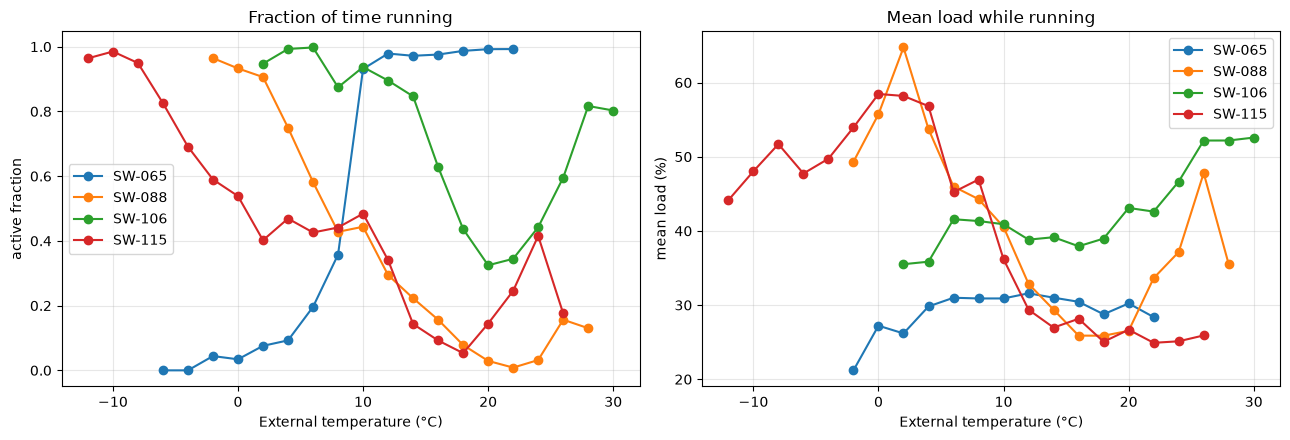

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

for d, g in t2_activity.groupby("hwid"):
    axes[0].plot(g["temp_bin"], g["active_fraction"], marker="o", label=d)
    axes[1].plot(g["temp_bin"], g["mean_load_running"], marker="o", label=d)

axes[0].set_title("Fraction of time running")
axes[0].set_ylabel("active fraction")
axes[1].set_title("Mean load while running")
axes[1].set_ylabel("mean load (%)")
for a in axes:
    a.set_xlabel("External temperature (°C)")
    a.grid(alpha=0.3)
    a.legend()
plt.tight_layout()
plt.show()

In [30]:
# Which effect dominates for each device: switching on/off, or modulating?
# The comparison separates "how often it runs" from "how hard it runs".
print("Correlations below are computed across temperature BINS, not raw\n"
      "minutes: n is the number of bins that passed the MIN_COUNT filter.\n")
print(f"{'device':8s} {'corr(active_frac, T)':>22s} {'corr(load|running, T)':>23s} {'n bins':>8s}")
for d, g in t2_activity.groupby("hwid"):
    g2 = g.dropna(subset=["mean_load_running"])
    c_act = g["active_fraction"].corr(g["temp_bin"])
    c_run = g2["mean_load_running"].corr(g2["temp_bin"]) if len(g2) > 2 else float("nan")
    print(f"{d:8s} {c_act:>22.3f} {c_run:>23.3f} {len(g):>8d}")

print()
print("Read the two columns against each other:")
print("  strong in column 1, weak in column 2 -> the device turns ON/OFF with")
print("     temperature; the apparent load correlation is a duty-cycle effect")
print("  weak in column 1, strong in column 2 -> the device runs either way and")
print("     genuinely modulates its load with temperature")

Correlations below are computed across temperature BINS, not raw
minutes: n is the number of bins that passed the MIN_COUNT filter.

device     corr(active_frac, T)   corr(load|running, T)   n bins
SW-065                    0.922                   0.531       15
SW-088                   -0.925                  -0.640       16
SW-106                   -0.605                   0.848       15
SW-115                   -0.890                  -0.818       20

Read the two columns against each other:
  strong in column 1, weak in column 2 -> the device turns ON/OFF with
     temperature; the apparent load correlation is a duty-cycle effect
  weak in column 1, strong in column 2 -> the device runs either way and
     genuinely modulates its load with temperature


### Three behaviours, not one

Mean load conflates two things a device can do when more capacity is needed:
run **more of the time**, or run **harder while on**. Separating them shows
the fleet contains three distinct behaviours.

| Device | Active fraction (range) | Load while running (range) |
|---|---|---|
| SW-065 | 0.00 → 0.99 | 21 → 32% (10 points) |
| SW-088 | 0.01 → 0.97 | 26 → 65% (39 points) |
| SW-106 | 0.33 → 1.00 | 36 → 53% (17 points) |
| SW-115 | 0.05 → 0.99 | 25 → 58% (34 points) |

**SW-065 barely modulates at all.** Its duty cycle swings across the entire
range (never running below −4 °C, running over 97% of the time above 10 °C)
while the load it draws when running stays near 30% regardless of temperature.
Its strong positive correlation is therefore *entirely* a duty-cycle effect:
the machine is simply switched off in cold weather rather than working in
reverse. This is what a cooling-only unit would look like, and reading `S1`
(Unit Mode) would confirm or refute it.

**SW-088 and SW-115 use both mechanisms in the same direction**: they run more
often *and* harder as it gets colder. These are the clearest heating-dominated
machines.

**SW-106 is the composite case.** Its duty cycle falls with temperature (99%
of the time near 5 °C, 33% near 20 °C) while the load it draws when running
*rises* (36% in the cold, 53% at 30 °C). The two effects partly cancel, which
is why its overall coefficient (−0.27) is the weakest in the fleet, not
because the relationship is weak, but because it is the sum of two opposing
ones. Without this decomposition the device would have been written off as
uncorrelated.

## 10. Sizing analysis
The assignment notes that the loading percentage *"can indicate issues related
to under-dimensioned or over-dimensioned devices"*. This section follows that
up: it is background to the task, not part of the objective, which is about
correlations with temperature.

A device often running near **100%** has no spare capacity at peak demand and
is likely **too small** for the plant it serves. One that stays at **low**
values is likely **too large**: much of the installed capacity is never used.

We look at load percentiles and at time spent in the extreme bands, counting
only the minutes the device is actually running. The 90% and 30% thresholds
are ours, not the manufacturer's: they rank the devices against each other,
they certify nothing.

In [31]:
t2_HIGH_LOAD = 90       # % above which the device is near its limit
t2_LOW_LOAD  = 30       # % below which the device is barely loaded

t2_df_active = t2_df_wide.where(sf.col("load_avg") > 0)

t2_sizing = t2_df_active.groupBy("hwid").agg(
    sf.count("*").alias("active_minutes"),
    sf.mean("load_avg").alias("mean_load"),
    sf.expr("percentile_approx(load_avg, 0.5)").alias("median"),
    sf.expr("percentile_approx(load_avg, 0.95)").alias("p95"),
    sf.mean(sf.when(sf.col("load_avg") >= t2_HIGH_LOAD, 1.0).otherwise(0.0)).alias("frac_high"),
    sf.mean(sf.when(sf.col("load_avg") <= t2_LOW_LOAD, 1.0).otherwise(0.0)).alias("frac_low"),
).orderBy("hwid")

t2_pdf_sizing = t2_sizing.toPandas()
t2_pdf_sizing.round(2)

,hwid,active_minutes,mean_load,median,p95,frac_high,frac_low
0,SW-065,68914,30.77,30.0,50.0,0.00,0.53
1,SW-088,71085,44.70,50.0,100.0,0.07,0.17
2,SW-106,68624,40.92,43.0,57.0,0.00,0.37
3,SW-115,102891,48.02,50.0,100.0,0.11,0.41


In [32]:
# Relative reading: rank the devices instead of forcing absolute labels
t2_pdf_sizing = t2_pdf_sizing.sort_values("mean_load", ascending=False)

print(f"{'device':8s} {'mean':>7s} {'median':>7s} {'p95':>7s} "
      f"{'>=' + str(t2_HIGH_LOAD) + '%':>8s} {'<=' + str(t2_LOW_LOAD) + '%':>8s}")
for _, r in t2_pdf_sizing.iterrows():
    print(f"{r['hwid']:8s} {r['mean_load']:6.1f}% {r['median']:6.1f}% "
          f"{r['p95']:6.1f}% {100 * r['frac_high']:7.1f}% {100 * r['frac_low']:7.1f}%")

print()
t2_hi = t2_pdf_sizing.iloc[0]
t2_lo = t2_pdf_sizing.iloc[-1]
print(f"Highest duty cycle: {t2_hi['hwid']} (mean {t2_hi['mean_load']:.1f}%, "
      f"{100 * t2_hi['frac_high']:.1f}% of active time at or above {t2_HIGH_LOAD}%)")
print(f"Lowest duty cycle:  {t2_lo['hwid']} (mean {t2_lo['mean_load']:.1f}%, "
      f"{100 * t2_lo['frac_low']:.1f}% of active time at or below {t2_LOW_LOAD}%)")

device      mean  median     p95    >=90%    <=30%
SW-115     48.0%   50.0%  100.0%    11.0%    40.8%
SW-088     44.7%   50.0%  100.0%     6.7%    17.3%
SW-106     40.9%   43.0%   57.0%     0.5%    36.7%
SW-065     30.8%   30.0%   50.0%     0.0%    53.0%

Highest duty cycle: SW-115 (mean 48.0%, 11.0% of active time at or above 90%)
Lowest duty cycle:  SW-065 (mean 30.8%, 53.0% of active time at or below 30%)


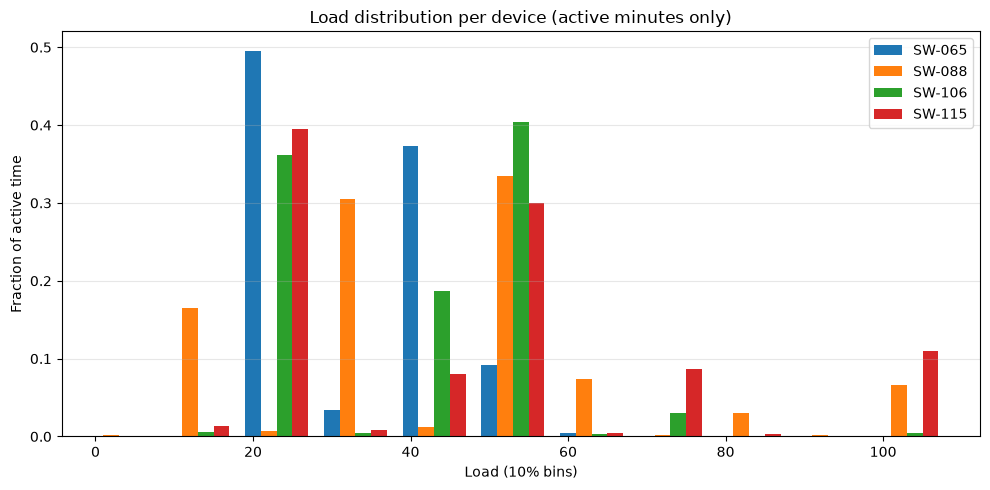

In [33]:
# Load distribution per device (histogram computed in Spark)
t2_BIN_LOAD = 10        # bin width, percentage points

t2_hist = (
    t2_df_active.withColumn("load_bin",
                            sf.floor(sf.col("load_avg") / t2_BIN_LOAD) * t2_BIN_LOAD)
                .groupBy("hwid", "load_bin")
                .count()
                .orderBy("hwid", "load_bin")
                .toPandas()
)

# Normalising to a fraction of time, rather than raw counts, makes devices
# with histories of different length comparable
t2_hist["fraction"] = t2_hist.groupby("hwid")["count"].transform(lambda s: s / s.sum())

fig, ax = plt.subplots(figsize=(10, 5))
t2_devices = sorted(t2_hist["hwid"].unique())
bar_w = t2_BIN_LOAD / (len(t2_devices) + 1)
for i, d in enumerate(t2_devices):
    g = t2_hist[t2_hist["hwid"] == d]
    ax.bar(g["load_bin"] + i * bar_w, g["fraction"], width=bar_w, label=d)
ax.set_xlabel(f"Load ({t2_BIN_LOAD}% bins)")
ax.set_ylabel("Fraction of active time")
ax.set_title("Load distribution per device (active minutes only)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Two groups, and a hint about capacity control

| Device | Mean | Median | p95 | Time ≥90% | Time ≤30% |
|---|---|---|---|---|---|
| SW-115 | 48.0% | 50% | 100% | 11.0% | 40.8% |
| SW-088 | 44.7% | 50% | 100% | 6.7% | 17.3% |
| SW-106 | 40.9% | 43% | 57% | 0.5% | 36.7% |
| SW-065 | 30.8% | 30% | 50% | ~0% | 53.0% |

**SW-115 and SW-088 reach saturation**: p95 at 100%, and 11% and 7% of running
time above 90% load. Little headroom at peak.

**SW-106 and SW-065 never exceed 57% and 50%.** SW-065 sits below 30% for over
half its running time, and is idle most of the winter besides.

Two caveats. Reading high load as undersized and low load as oversized is
standard engineering reasoning, not something the assignment states. And
excluding idle minutes *understates* over-sizing: a machine that is off half
the time arguably does not need to run at all.

A third caveat matters more than the other two: the dataset says nothing about
the plants these machines serve. SW-115 working twice as hard as SW-065 may
simply mean it serves a larger or more demanding building. If the four were
comparable the figures would point to uneven sizing, but that premise cannot
be checked here.

The percentiles also hint at something unrelated to sizing. SW-115 and SW-088
sit at exactly 50% median and 100% p95, which is what two on/off compressors
would produce, while SW-106 (43%, 57%) and SW-065 (30%, 50%) take values no
pair of on/off units can give. The next section tests whether that difference
is real.

## 11. Cross-check: is capacity quantised or continuous?

`load_avg` has been read throughout as delivered power. That reading assumes
the compressors modulate. If instead they were plain on/off units, two per
circuit, capacity could only ever take three values (0, 50 or 100) and
`load_avg` would be counting running units rather than measuring power.

The percentiles above already point one way: SW-106 peaks at 57% and SW-065 at
50%, values no pair of on/off compressors can produce. Counting the distinct
values each device actually takes settles it, and uses the engine status flags
(`S117`, `S118` for circuit 1, `S169`, `S170` for circuit 2) that the
assignment opens the task with.

In [34]:
# How many distinct capacity values does each device take? On/off compressors
# would give at most three per circuit; modulation gives many.
t2_quant = (
    t2_df_wide.groupBy("hwid")
              .agg(*[sf.expr(f"count(distinct {c})").alias(f"n_{c}")
                     for c in t2_LOAD_COLS])
              .orderBy("hwid")
              .toPandas()
)
print(t2_quant.to_string(index=False))
print()
for _, r in t2_quant.iterrows():
    n_max = max(r[f"n_{c}"] for c in t2_LOAD_COLS)
    mode = "on/off staging" if n_max <= 4 else "continuous modulation"
    print(f"  {r['hwid']}: {n_max} distinct levels -> {mode}")

  hwid  n_S125  n_S181
SW-065      11      10
SW-088      19      19
SW-106      11      14
SW-115      10       9

  SW-065: 11 distinct levels -> continuous modulation
  SW-088: 19 distinct levels -> continuous modulation
  SW-106: 14 distinct levels -> continuous modulation
  SW-115: 10 distinct levels -> continuous modulation


## 12. Saving the results

A subtlety about **where** Spark writes. `df.write.parquet("/opt/...")` is
executed by the *executors*, each writing its own partitions to its **own
local disk**. Even with `coalesce(1)` the single remaining partition is still
written by an executor, which may well be running on a worker node where
`/opt/mapd-project` does not exist — the job then fails with
`Mkdirs failed to create file:/opt/...`.

There are two correct options:

- write to **S3**, which every node can reach (`s3a://...`);
- or, for results already small enough to fit in the driver, collect them and
  write from the **driver** with pandas, which runs on the master.

All the outputs here are aggregates of a few dozen to a few thousand rows, so
the second option is both simpler and sufficient.

In [35]:
t2_OUT_DIR = "/opt/mapd-project/results_ad2"
os.makedirs(t2_OUT_DIR, exist_ok=True)

# Written by the driver (pandas), not by the executors: no distributed
# filesystem needed, and the file lands on the master where we can find it.
t2_pdf_profile.to_csv(f"{t2_OUT_DIR}/ad2_temp_profile.csv", index=False)
t2_prof_dev.to_csv(f"{t2_OUT_DIR}/ad2_temp_profile_per_device.csv", index=False)
t2_pdf_corr.to_csv(f"{t2_OUT_DIR}/ad2_correlations.csv", index=False)
t2_pdf_sizing.to_csv(f"{t2_OUT_DIR}/ad2_sizing.csv", index=False)
t2_activity.to_csv(f"{t2_OUT_DIR}/ad2_activity_vs_temperature.csv", index=False)
t2_weekly.to_csv(f"{t2_OUT_DIR}/ad2_circuits_weekly.csv", index=False)

print(f"Results written to {t2_OUT_DIR}/")
for f in ["ad2_temp_profile", "ad2_temp_profile_per_device", "ad2_correlations",
          "ad2_sizing", "ad2_activity_vs_temperature", "ad2_circuits_weekly"]:
    print(f"  {f}.csv")

Results written to /opt/mapd-project/results_ad2/
  ad2_temp_profile.csv
  ad2_temp_profile_per_device.csv
  ad2_correlations.csv
  ad2_sizing.csv
  ad2_activity_vs_temperature.csv
  ad2_circuits_weekly.csv


## 13. Conclusions

**One circuit fails during the period.** SW-088's second circuit stops in the
first week of January 2021 and never restarts, while circuit 1 keeps running
for the remaining three months at a visibly higher load. The weekly profiles
show a step change at a date, not a constant offset, and the gap between the
two circuits swings by 12.7 percentage points against 1.0–3.1 on the other
devices. This also explains why SW-088 was the only machine whose circuits
correlate differently with temperature: circuit 2 simply has data for half the
period.

**The fleet-level correlation is meaningless.** Pooled, r = −0.16, reading as
"almost no relationship". Separated, three devices correlate strongly negative
and one strongly positive: the pooled figure describes no machine in the data.

**The relationship is real but not linear.** The binned profile traces a U,
minimal around 18–20 °C and rising at both extremes, because compressor work
scales with the thermal gap in either direction. The devices cover different
branches of that curve, though — three produce the cold side, SW-065 only the
warm one — so the pooled U reflects the composition of the fleet rather than
the response of a typical machine.

**The devices get there differently.** SW-065 is essentially on/off: idle from
December onwards, fixed at ~30% whenever running, so its positive correlation
is a duty-cycle effect rather than reverse operation. SW-088 and SW-115 run
both more often and harder as it gets colder. SW-106 does the two in opposite
directions, which is why its coefficient looks weak while neither trend is.

**On sizing**, SW-115 and SW-088 hit full capacity with little headroom;
SW-106 and SW-065 never exceed 57% and 50%. Whether that reflects uneven
sizing or simply different buildings cannot be decided from this dataset,
which carries no information about the plants being served.

### Limitations

The warm branch of the U rests on an order of magnitude fewer observations
than the cold one.

SW-065's positive correlation is confounded with time: the device ran through
October and November and was off from December to March, so it may follow a
seasonal schedule rather than respond to temperature itself. The two are
indistinguishable in these data.

Six months is too short to detect mechanical deterioration, which the
assignment lists among the things load can reveal. Comparing October against
March at equal temperature would not isolate wear either: the months differ in
humidity, solar gain and occupancy.

Correlation is not causation — set-point, occupancy and maintenance drive both
variables and are absent from the data.

`S1`, `S2`, `S123` and `S179` were not read. They would turn *"SW-065 is
probably a cooling unit"* into a measured fact.